# 美式期权建模：CRR 二叉树、提前行权与风险测度

本Notebook实现第一版美式股票期权定价器。范围有意保持简单：单一标的、常数波动率、平坦无风险利率、连续股息率，以及CRR重组二叉树。

它将输出：

- 美式或欧式Call/Put的PV；
- 每个树节点的继续持有价值与提前行权决定；
- 美式期权的提前行权边界；
- Delta、Gamma、Vega、Rho、股息敏感度和Theta；
- 基础数值验证。

注意：这是理论与数值验证版本，不使用真实市场数据。生产版本将把平坦利率、连续股息率和常数波动率扩展为曲线、离散分红表和波动率曲面。

In [2]:
from dataclasses import dataclass, replace
import math
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## 1. 合同、市场和数值设置

这三个对象必须分开：

- OptionContract：交易确认书中的固定条款；
- MarketData：估值日随市场变动的数据；
- TreeConfig：数值精度设置，并非市场风险因子。

In [3]:
@dataclass(frozen=True)
class OptionContract:
    strike: float
    maturity: float              # 剩余期限，单位：年
    option_type: Literal['call', 'put']
    style: Literal['american', 'european'] = 'american'
    multiplier: float = 1.0

    def intrinsic(self, spot):
        sign = 1.0 if self.option_type.lower() == 'call' else -1.0
        return np.maximum(sign * (np.asarray(spot) - self.strike), 0.0)


@dataclass(frozen=True)
class MarketData:
    spot: float
    rate: float                   # 连续复利无风险利率 r
    dividend_yield: float         # 连续股息率 q
    volatility: float             # 年化隐含波动率 sigma


@dataclass(frozen=True)
class TreeConfig:
    steps: int = 500
    exercise_tolerance: float = 1e-12


@dataclass
class TreeResult:
    price: float
    probability_up: float
    up_factor: float
    down_factor: float
    stock_nodes: list
    value_nodes: list
    exercise_nodes: list

## 2. CRR美式期权定价器

风险中性上涨概率为：

$$p_{up}=\frac{e^{(r-q)\Delta t}-d}{u-d}$$

在每个中间节点，先计算继续持有价值，再与立即行权价值比较：

$$V_{i,j}=\max\left(G_{i,j},e^{-r\Delta t}[p_{up}V_{i+1,j+1}+(1-p_{up})V_{i+1,j}]\right)$$

这正是文章中Snell包络递推的重组二叉树实现。

In [4]:
def validate_inputs(option: OptionContract, market: MarketData, config: TreeConfig):
    if option.option_type.lower() not in {'call', 'put'}:
        raise ValueError("option_type must be 'call' or 'put'")
    if option.style.lower() not in {'american', 'european'}:
        raise ValueError("style must be 'american' or 'european'")
    if option.strike <= 0 or option.maturity <= 0 or option.multiplier <= 0:
        raise ValueError('strike, maturity and multiplier must be positive')
    if market.spot <= 0 or market.volatility <= 0:
        raise ValueError('spot and volatility must be positive')
    if config.steps < 1:
        raise ValueError('steps must be at least 1')


def price_crr_tree(
    option: OptionContract,
    market: MarketData,
    config: TreeConfig = TreeConfig(),
) -> TreeResult:
    """使用重组CRR二叉树定价美式或欧式股票期权。"""
    validate_inputs(option, market, config)

    n_steps = config.steps
    dt = option.maturity / n_steps
    up = math.exp(market.volatility * math.sqrt(dt))
    down = 1.0 / up
    discount = math.exp(-market.rate * dt)

    # p_up是风险中性上涨概率；不要将它命名为q，q通常代表股息率。
    growth = math.exp((market.rate - market.dividend_yield) * dt)
    p_up = (growth - down) / (up - down)

    if not 0.0 < p_up < 1.0:
        raise ValueError(
            'Risk-neutral probability is outside (0, 1). '
            'Check market inputs or increase tree steps.'
        )

    # 第t层有t+1个重组节点；索引j表示截至t期累计上涨次数。
    stock_nodes = []
    for t in range(n_steps + 1):
        j = np.arange(t + 1)
        stock_nodes.append(market.spot * up ** j * down ** (t - j))

    value_nodes = [None] * (n_steps + 1)
    exercise_nodes = [None] * (n_steps + 1)

    # 到期日必须结算，故价值就是到期收益。
    terminal_intrinsic = option.intrinsic(stock_nodes[-1])
    value_nodes[-1] = terminal_intrinsic
    exercise_nodes[-1] = terminal_intrinsic > 0.0

    # 从到期日向估值日回推。
    for t in range(n_steps - 1, -1, -1):
        continuation = discount * (
            p_up * value_nodes[t + 1][1:]
            + (1.0 - p_up) * value_nodes[t + 1][:-1]
        )
        intrinsic = option.intrinsic(stock_nodes[t])

        if option.style.lower() == 'american':
            value_nodes[t] = np.maximum(intrinsic, continuation)
            exercise_nodes[t] = (
                (intrinsic > 0.0)
                & (intrinsic >= continuation - config.exercise_tolerance)
            )
        else:
            value_nodes[t] = continuation
            exercise_nodes[t] = np.zeros(t + 1, dtype=bool)

    return TreeResult(
        price=float(value_nodes[0][0] * option.multiplier),
        probability_up=float(p_up),
        up_factor=float(up),
        down_factor=float(down),
        stock_nodes=stock_nodes,
        value_nodes=value_nodes,
        exercise_nodes=exercise_nodes,
    )


def black_scholes_european(option: OptionContract, market: MarketData) -> float:
    """含连续股息率的欧式Black-Scholes价格，用于数值验证。"""
    if option.maturity <= 0:
        return float(option.intrinsic(market.spot) * option.multiplier)

    sqrt_t = math.sqrt(option.maturity)
    sigma_sqrt_t = market.volatility * sqrt_t
    d1 = (
        math.log(market.spot / option.strike)
        + (market.rate - market.dividend_yield + 0.5 * market.volatility ** 2)
        * option.maturity
    ) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t

    discount_r = math.exp(-market.rate * option.maturity)
    discount_q = math.exp(-market.dividend_yield * option.maturity)

    if option.option_type.lower() == 'call':
        price = market.spot * discount_q * norm.cdf(d1) - option.strike * discount_r * norm.cdf(d2)
    else:
        price = option.strike * discount_r * norm.cdf(-d2) - market.spot * discount_q * norm.cdf(-d1)

    return float(price * option.multiplier)

## 3. 基准交易：美式看跌期权

这是一组人为设定的理论参数。后续接入市场数据时，只需替换MarketData中的值，或把它升级为曲线和波动率曲面。

In [5]:
american_put = OptionContract(
    strike=100.0,
    maturity=1.0,
    option_type='put',
    style='american',
    multiplier=1.0,
)

market = MarketData(
    spot=100.0,
    rate=0.05,
    dividend_yield=0.02,
    volatility=0.25,
)

config = TreeConfig(steps=500)
result = price_crr_tree(american_put, market, config)

print(f'American put PV: {result.price:.6f}')
print(f'CRR up factor u: {result.up_factor:.6f}')
print(f'CRR down factor d: {result.down_factor:.6f}')
print(f'Risk-neutral up probability: {result.probability_up:.6f}')

American put PV: 8.562690
CRR up factor u: 1.011243
CRR down factor d: 0.988882
Risk-neutral up probability: 0.499888


## 4. 提前行权边界

对美式Put，行权区通常在低股价区域。每期显示的边界是仍然值得提前行权的最高股价。对美式Call，则显示值得提前行权的最低股价。

,step,time,boundary
29,29,0.058,72.308402
30,30,0.060,71.504472
31,31,0.062,72.308402
32,32,0.064,71.504472
33,33,0.066,72.308402
34,34,0.068,71.504472
35,35,0.070,72.308402
36,36,0.072,71.504472
37,37,0.074,72.308402
38,38,0.076,71.504472


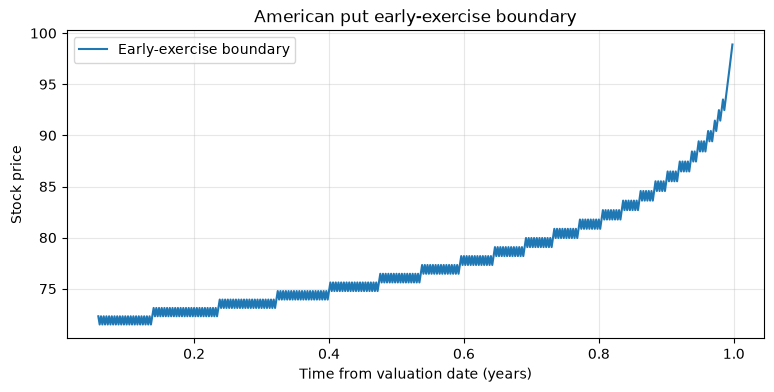

In [6]:
def exercise_boundary(result: TreeResult, option: OptionContract) -> pd.DataFrame:
    records = []
    for t, (spots, exercise) in enumerate(zip(result.stock_nodes[:-1], result.exercise_nodes[:-1])):
        exercise_spots = spots[exercise]
        if len(exercise_spots) == 0:
            boundary = np.nan
        elif option.option_type.lower() == 'put':
            boundary = float(np.max(exercise_spots))
        else:
            boundary = float(np.min(exercise_spots))
        records.append({'step': t, 'time': t * option.maturity / (len(result.stock_nodes) - 1), 'boundary': boundary})
    return pd.DataFrame(records)


boundary_df = exercise_boundary(result, american_put)
display(boundary_df.dropna().head(10))

plt.figure(figsize=(9, 4))
plt.plot(boundary_df['time'], boundary_df['boundary'], label='Early-exercise boundary')
plt.xlabel('Time from valuation date (years)')
plt.ylabel('Stock price')
plt.title('American put early-exercise boundary')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. 风险测度：bump-and-revalue Greeks

美式期权在提前行权边界附近存在非线性和策略切换，因此第一版风险模块采用完整重估，而不是直接套欧式Black-Scholes Greeks。

- Delta：Spot上下各变动1个货币单位；
- Gamma：由同一组Spot冲击得到；
- Vega：隐含波动率上下各变动1个百分点；
- Rho：利率上下各平移1bp；
- Dividend sensitivity：股息率上下各平移1bp；
- Theta：估值日向前滚动一个日历日。

In [7]:
def risk_report(
    option: OptionContract,
    market: MarketData,
    config: TreeConfig,
    spot_bump: float = 1.0,
    vol_bump: float = 0.01,
    rate_bump: float = 0.0001,
    dividend_bump: float = 0.0001,
    day_count: float = 365.0,
) -> pd.Series:
    if market.volatility <= vol_bump:
        raise ValueError('vol_bump must be smaller than volatility')
    if option.maturity <= 1.0 / day_count:
        raise ValueError('maturity must exceed one day for theta')

    base = price_crr_tree(option, market, config).price
    spot_up = price_crr_tree(option, replace(market, spot=market.spot + spot_bump), config).price
    spot_down = price_crr_tree(option, replace(market, spot=market.spot - spot_bump), config).price
    vol_up = price_crr_tree(option, replace(market, volatility=market.volatility + vol_bump), config).price
    vol_down = price_crr_tree(option, replace(market, volatility=market.volatility - vol_bump), config).price
    rate_up = price_crr_tree(option, replace(market, rate=market.rate + rate_bump), config).price
    rate_down = price_crr_tree(option, replace(market, rate=market.rate - rate_bump), config).price
    div_up = price_crr_tree(option, replace(market, dividend_yield=market.dividend_yield + dividend_bump), config).price
    div_down = price_crr_tree(option, replace(market, dividend_yield=market.dividend_yield - dividend_bump), config).price
    rolled_option = replace(option, maturity=option.maturity - 1.0 / day_count)
    theta_1d = price_crr_tree(rolled_option, market, config).price - base

    return pd.Series({
        'PV': base,
        'PV (spot + bump)': spot_up,
        'PV (spot - bump)': spot_down,
        'Delta per 1 spot unit': (spot_up - spot_down) / (2.0 * spot_bump),
        'Gamma per spot unit squared': (spot_up - 2.0 * base + spot_down) / spot_bump ** 2,
        'Vega per 1 vol point': (vol_up - vol_down) / 2.0,
        'Rho per 1 bp': (rate_up - rate_down) / 2.0,
        'Dividend sensitivity per 1 bp': (div_up - div_down) / 2.0,
        'Theta per calendar day': theta_1d,
    })


risk = risk_report(american_put, market, config)
display(risk.to_frame('Value'))

,Value
PV,8.562690
PV (spot + bump),8.158998
PV (spot - bump),8.997269
Delta per 1 spot unit,-0.419135
Gamma per spot unit squared,0.030887
Vega per 1 vol point,0.381084
Rho per 1 bp,-0.003633
Dividend sensitivity per 1 bp,0.003094
Theta per calendar day,-0.009780


## 6. 数值验证

在接入真实市场数据前，先检查模型必须满足的理论性质。

In [8]:
# 1) 美式Put不应低于对应欧式Put。
european_put = replace(american_put, style='european')
american_put_pv = price_crr_tree(american_put, market, config).price
european_put_pv = price_crr_tree(european_put, market, config).price
assert american_put_pv >= european_put_pv - 1e-12

# 2) 无分红股票的美式Call不应提前行权，树模型价格应等于欧式树模型价格。
no_dividend_market = replace(market, dividend_yield=0.0)
american_call = OptionContract(100.0, 1.0, 'call', 'american')
european_call = replace(american_call, style='european')
american_call_pv = price_crr_tree(american_call, no_dividend_market, config).price
european_call_pv = price_crr_tree(european_call, no_dividend_market, config).price
assert abs(american_call_pv - european_call_pv) < 1e-10

# 3) 欧式树模型应随着步数增加接近Black-Scholes解析解。
step_grid = [50, 100, 250, 500, 1000]
convergence = []
for steps in step_grid:
    tree_pv = price_crr_tree(european_put, market, TreeConfig(steps=steps)).price
    convergence.append({'steps': steps, 'CRR European put': tree_pv})

convergence_df = pd.DataFrame(convergence)
bs_pv = black_scholes_european(european_put, market)
convergence_df['Black-Scholes European put'] = bs_pv
convergence_df['absolute error'] = (convergence_df['CRR European put'] - bs_pv).abs()

display(convergence_df)
print('All core validation checks passed.')

,steps,CRR European put,Black-Scholes European put,absolute error
0,50,8.178596,8.226837,0.048241
1,100,8.202685,8.226837,0.024152
2,250,8.217169,8.226837,0.009668
3,500,8.222002,8.226837,0.004835
4,1000,8.224419,8.226837,0.002418


All core validation checks passed.


## 下一步

下一版将依次加入：

1. 离散现金分红与除息日前提前行权；
2. 利率曲线和分桶Rho/PV01；
3. 隐含波动率曲面；
4. 有限差分方法，与CRR树交叉验证；
5. 真实市场期权报价的校准与误差分析；
6. 面向FRTB的Equity Delta、Vega和Curvature输出。